In [0]:
storage_account_name = "datalake60306249"
storage_account_key = "7G2tmMYVeA+Zamq6y+efmYamIo1OeBnKxzRUeVMqN91qn7bANbEEq0szMvcTHBFgIayEs7X0RgNo+ASt1ApzIg=="
spark.conf.set(
f"fs.azure.account.key.{storage_account_name}.dfs.core.windows.net",
storage_account_key
)

In [0]:
enriched_reviews_path = "abfss://processed@datalake60306249.dfs.core.windows.net/enriched_reviews/"
enriched_df = spark.read.parquet(enriched_reviews_path)

In [0]:
features_v1_df = enriched_df.select(
"asin",
"title",
"brand",
"price",
"reviewerID",
"overall",
"summary",
"reviewText",
"helpful",
"reviewTime",
"review_year"
)

In [0]:
gold_path = "abfss://curated@datalake60306249.dfs.core.windows.net/features_v1/"
features_v1_df.write.mode("overwrite").parquet(gold_path)

In [0]:
gold_df = spark.read.parquet(gold_path)
gold_df.printSchema()
display(gold_df.limit(5))
print("Final row count:", gold_df.count())

root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- reviewerID: string (nullable = true)
 |-- overall: double (nullable = true)
 |-- summary: string (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- helpful: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- reviewTime: string (nullable = true)
 |-- review_year: integer (nullable = true)



asin,title,brand,price,reviewerID,overall,summary,reviewText,helpful,reviewTime,review_year
B008O0ZRNS,"iXCC Quality iPad To HDMI Cable Adapter For Apple iPad, iPad 2, the New iPad 3, iPhone 4, iPhone 4S And iTouch 4",null,18.99,A3EB7PIM7O6JXA,5.0,Works great,"I cannot compare it to the name brand because I do not have the name brand. But, with an HDMI cable and an HD tv with a HD signal, I can tell no difference between the signal from the ipad and my HD DVR.","List(0, 0)","01 11, 2013",2013
B008O0ZRNS,"iXCC Quality iPad To HDMI Cable Adapter For Apple iPad, iPad 2, the New iPad 3, iPhone 4, iPhone 4S And iTouch 4",null,18.99,A8GQ7G2HRJMES,2.0,It worked ofr a little while,"It is no longer available because it is not very durable and the neck tore and it was rendered useless. This occurred during routine use. Hey, make a durable product. Geez!! There are others out there, shop there.","List(0, 0)","02 8, 2013",2013
B008O0ZRNS,"iXCC Quality iPad To HDMI Cable Adapter For Apple iPad, iPad 2, the New iPad 3, iPhone 4, iPhone 4S And iTouch 4",null,18.99,ATDM0XN2MJG2U,5.0,Ipad to HDMI cable,The product arrived on time. It is a very handy piece to have for us who travel for presentations. Small enough to lug around.,"List(0, 0)","02 20, 2013",2013
B008O0ZRNS,"iXCC Quality iPad To HDMI Cable Adapter For Apple iPad, iPad 2, the New iPad 3, iPhone 4, iPhone 4S And iTouch 4",null,18.99,A263O1568N5W0S,5.0,Watch Netflix 1080p,Hooked to my Ipad4 to my new Vizo Smart Tv and watched the best picture I've ever seen o tv. Bozo is just a mid range led but with the retina display hooked directly to my HDMI it couldn't be any better. Use the tv without the retina display IPad and the difference is clear,"List(0, 0)","01 12, 2013",2013
B008O0ZRNS,"iXCC Quality iPad To HDMI Cable Adapter For Apple iPad, iPad 2, the New iPad 3, iPhone 4, iPhone 4S And iTouch 4",null,18.99,A310LDM40EGGHN,4.0,Product worked well.,"This product worked so well, that after loaning to a friend, it has not been returned. It does not charge your device though.","List(0, 0)","12 17, 2013",2013


Final row count: 28686259


In [0]:
# Counting rows and columns

row_count = gold_df.count()
col_count = len(gold_df.columns)
print(f"Rows: {row_count}, Columns: {col_count}")

Rows: 28686259, Columns: 11


In [0]:
# Check for nulls

from pyspark.sql.functions import col, isnan, when, count
gold_df.select([
    count(when(col(c).isNull(), c)).alias(f"{c}_nulls")
    for c in ["reviewText", "overall", "asin", "reviewerID"]
]).show()

+----------------+-------------+----------+----------------+
|reviewText_nulls|overall_nulls|asin_nulls|reviewerID_nulls|
+----------------+-------------+----------+----------------+
|               0|            0|         0|               0|
+----------------+-------------+----------+----------------+



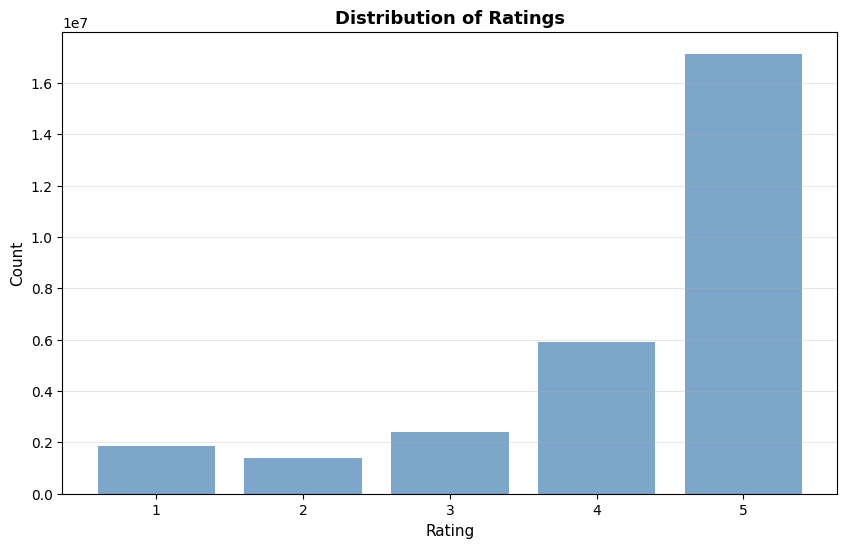

In [0]:
# 1. Rating distribution

import matplotlib.pyplot as plt

# Count reviews for each rating
rating_counts = gold_df.groupBy("overall").count().toPandas()
rating_counts = rating_counts.sort_values("overall")

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(rating_counts["overall"], rating_counts["count"])
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of Ratings")
plt.show()

# Print the actual numbers
print(rating_counts)

The distribution is heavily skewed toward 5-star reviews (~43% of all reviews) compared to 1-star reviews (~5%). This class imbalance means ML models need special handling (class weights) to learn from minority classes. If a model just predicts "5-star" for everything, it gets 43% accuracy without learning anything—our features must beat this baseline.

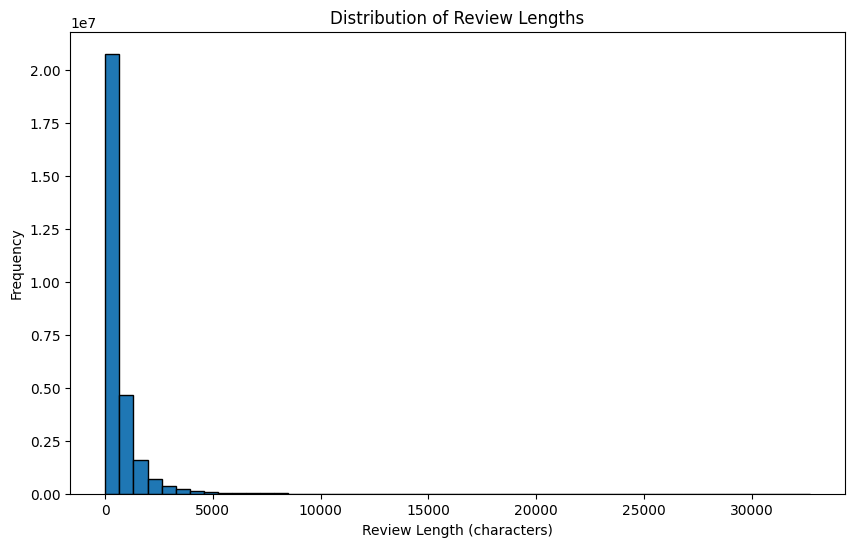

In [0]:
# 2. Review length distribution

from pyspark.sql.functions import length

# Calculate review length
gold_df_with_length = gold_df.withColumn("review_length", length("reviewText"))

# Convert to Pandas
length_data = gold_df_with_length.select("review_length").toPandas()

# Plot
length_data["review_length"].hist(bins=50, figsize=(10, 6))
plt.xlabel("Review Length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Review Lengths")
plt.show()

# Print statistics
print(f"Average: {length_data['review_length'].mean():.2f} characters")
print(f"Median: {length_data['review_length'].median():.2f} characters")
print(f"Max: {length_data['review_length'].max()} characters"

In [0]:
The distribution is heavily skewed toward 5-star reviews (~43% of all reviews) compared to 1-star reviews (~5%). This class imbalance means ML models need special handling (class weights) to learn from minority classes. If a model just predicts "5-star" for everything, it gets 43% accuracy without learning anything—our features must beat this baseline.

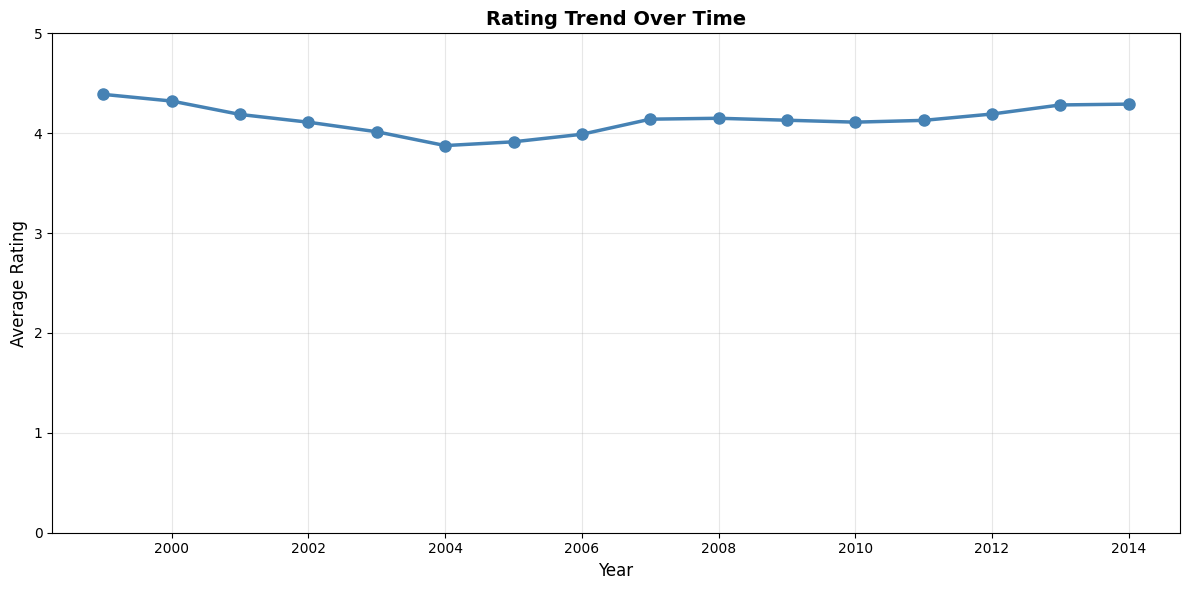


Rating trend by year:
    review_year  avg_rating
0          1999    4.388889
1          2000    4.321909
2          2001    4.187694
3          2002    4.110151
4          2003    4.014378
5          2004    3.876139
6          2005    3.913986
7          2006    3.989448
8          2007    4.140601
9          2008    4.149560
10         2009    4.130006
11         2010    4.110751
12         2011    4.128575
13         2012    4.192205
14         2013    4.283035
15         2014    4.291347


In [0]:
# 3. rating over time distribution

from pyspark.sql.functions import avg
import matplotlib.pyplot as plt

# Aggregate average rating by year
rating_trend = gold_df.groupBy("review_year").agg(
    avg("overall").alias("avg_rating")
).orderBy("review_year").toPandas()

# Create temporal trend line chart
plt.figure(figsize=(12, 6))
plt.plot(rating_trend["review_year"], rating_trend["avg_rating"], 
         marker='o', linewidth=2.5, markersize=8, color='steelblue')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)
plt.title("Rating Trend Over Time", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

print("\nRating trend by year:")
print(rating_trend)

 Most reviews cluster around 500 characters, but there's a long tail extending to 30,000+ characters. This shows that review length varies widely at all star ratings (1-star and 5-star reviews can both be short or long). Length alone won't predict ratings, but combined with sentiment features it becomes useful—a long, detailed 1-star complaint carries different weight than a short 1-star review

These visualizations revealed that:
- Class imbalance requires careful model handling
- Simple features (length) need to be combined with semantic features (sentiment, embeddings)
- Data quality is high (<1% missing values), ready for feature engineering

In [0]:
# Create a sample data (~300,000 reviews)
# Stratified sampling by year

from pyspark.sql.functions import rand, row_number, col
from pyspark.sql.window import Window

sample_size = 300000
seed = 42

# Calculate samples per year more carefully
year_counts = gold_df.groupBy("review_year").count().collect()
total_reviews = gold_df.count()

# Calculate fraction to sample
sample_fraction = sample_size / total_reviews

print(f"Sample fraction: {sample_fraction:.4f}")

# Use simple random sampling with fraction
df_sampled = gold_df.sample(fraction=sample_fraction, seed=seed)

print(f"Sampled rows: {df_sampled.count()}")

# Check distribution
print("\nYear distribution:")
df_sampled.groupBy("review_year").count().orderBy("review_year").show()

print("\nRating distribution:")
df_sampled.groupBy("overall").count().orderBy("overall").show()

Sample fraction: 0.0105
Sampled rows: 300255

Year distribution:
+-----------+------+
|review_year| count|
+-----------+------+
|       1999|    10|
|       2000|   142|
|       2001|   272|
|       2002|   440|
|       2003|   654|
|       2004|   962|
|       2005|  1722|
|       2006|  2763|
|       2007|  6417|
|       2008|  8767|
|       2009| 12475|
|       2010| 18391|
|       2011| 30780|
|       2012| 50354|
|       2013|105374|
|       2014| 60732|
+-----------+------+


Rating distribution:
+-------+------+
|overall| count|
+-------+------+
|    1.0| 19389|
|    2.0| 14719|
|    3.0| 25305|
|    4.0| 61368|
|    5.0|179474|
+-------+------+



In [0]:
# Sanity check

# Check schema matches original
df_sampled.printSchema()
# Compare rating distribution with original dataset
gold_df.groupBy("overall").count().orderBy("overall").show()
df_sampled.groupBy("overall").count().orderBy("overall").show()

root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- reviewerID: string (nullable = true)
 |-- overall: double (nullable = true)
 |-- summary: string (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- helpful: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- reviewTime: string (nullable = true)
 |-- review_year: integer (nullable = true)

+-------+--------+
|overall|   count|
+-------+--------+
|    1.0| 1846404|
|    2.0| 1394952|
|    3.0| 2415802|
|    4.0| 5893781|
|    5.0|17135320|
+-------+--------+

+-------+------+
|overall| count|
+-------+------+
|    1.0| 19348|
|    2.0| 14428|
|    3.0| 25277|
|    4.0| 61683|
|    5.0|179308|
+-------+------+



In [0]:
# No.of rows and columns in sampled data

row_count = df_sampled.count()
col_count = len(df_sampled.columns)
print(f"Rows: {row_count}, Columns: {col_count}")

Rows: 300044, Columns: 11


In [0]:
#Writing it to the gold layer 

sampled_gold_path = (
f"abfss://curated@{storage_account_name}.dfs.core.windows.net/"
"features_v1_sampled/"
)
df_sampled.write \
.mode("overwrite") \
.parquet(sampled_gold_path)